## Temperature analysis - Notebook description


- **Dataset:** CERRA 2 m temperature over Italy (~5.5 km)
- **Reference period:** 1985–2014
- **Recent period:** 2020–2025
- **Season:** May–September (MJJAS)
- Daily mean, Tmax and Tmin are derived from 3-hourly data and converted to °C.

### Metrics

- **Temperature change:** recent minus reference MJJAS mean T, Tmax and Tmin.
- **Extreme hot days:** days with Tmax above the local calendar-day **P90** of the 1985–2014 baseline.
- **Daytime heatwaves:** ≥3 consecutive days with **Tmax > P90**.
  - Heatwave days
  - Number of events
  - Mean duration
  - Intensity above P90
- **Tropical nights:** **Tmin ≥ 20 °C**.
- **Compound day–night heatwaves:** ≥3 consecutive days with both **Tmax > P90** and **Tmin > P90**.
  - Compound heatwave days
  - Mean duration
  - Maximum seasonal duration
- **Fixed thresholds:** number of days with **Tmax ≥ 30 °C** and **Tmax ≥ 35 °C**.

### Sensitivity

The baseline is split into **1985–1999** and **2000–2014** to assess the sensitivity of P90-based extremes to warming within the reference period.

> Current percentile thresholds are calculated for each calendar day. Consider using moving-window percentile calculation instead

# Imports

In [87]:
import xarray as xr
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import CRS, Transformer
import warnings


In [2]:
current_path = Path.cwd()
base_path = current_path.parent
plots_path = base_path / "plots"
data_path = base_path / "data"

# 1) Load the dataset

In [3]:
# Baseline period, 3hourly data
file_path = data_path / "cerra_1984_2015_MJJAS_t2m_italy.nc"
ds_base = xr.open_dataset(file_path)

#Baseline period, daily mean data
file_path = data_path / "cerra_1984_2015_MJJAS_t2m_italy_dm.nc"
ds_base_dmean = xr.open_dataset(file_path)

#Baseline period, daily max data
file_path = data_path / "cerra_1984_2015_MJJAS_t2m_italy_dmax.nc"
ds_base_dmax = xr.open_dataset(file_path)

#Baseline period, daily min data
file_path = data_path / "cerra_1984_2015_MJJAS_t2m_italy_dmin.nc"
ds_base_dmin = xr.open_dataset(file_path)

# Present period, 3hourly data
file_path = data_path / "cerra_2020_2025_MJJAS_t2m_italy.nc"
ds_pres = xr.open_dataset(file_path)

# Present period, daily mean data
file_path = data_path / "cerra_2020_2025_MJJAS_t2m_italy_dm.nc"
ds_pres_dmean = xr.open_dataset(file_path)

#Present period, daily max data
file_path = data_path / "cerra_2020_2025_MJJAS_t2m_italy_dmax.nc"
ds_pres_dmax = xr.open_dataset(file_path)

#Present period, daily min data
file_path = data_path / "cerra_2020_2025_MJJAS_t2m_italy_dmin.nc"
ds_pres_dmin = xr.open_dataset(file_path)

In [4]:
# Select time period for the baseline 
ds_base = ds_base.sel(time=slice("1985", "2014"))
ds_base_dmean = ds_base_dmean.sel(time=slice("1985", "2014"))
ds_base_dmax = ds_base_dmax.sel(time=slice("1985", "2014"))
ds_base_dmin = ds_base_dmin.sel(time=slice("1985", "2014"))

In [5]:
# Check time coverage

datasets = {
    "ds_base": ds_base,
    "ds_base_dmean": ds_base_dmean,
    "ds_pres": ds_pres,
    "ds_pres_dmean": ds_pres_dmean,
}

for name, ds in datasets.items():
    time_var = None
    for coord in ["time", "valid_time"]:
        if coord in ds.coords:
            time_var = coord
            break

    if time_var is None:
        print(f"{name}: no time coordinate found")
        continue

    times = pd.to_datetime(ds[time_var].values)
    print(f"{name}:")
    print(f"  first = {times.min()}")
    print(f"  last  = {times.max()}")
    print(f"  n = {len(times)}")
    print(f"  years = {sorted(set(times.year))[:5]} ... {sorted(set(times.year))[-5:]}")
    print(f"  number of unique years = {len(set(times.year))}")
    print()

ds_base:
  first = 1985-05-01 00:00:00
  last  = 2014-09-30 21:00:00
  n = 37110
  years = [1985, 1986, 1987, 1988, 1989] ... [2010, 2011, 2012, 2013, 2014]
  number of unique years = 30

ds_base_dmean:
  first = 1985-05-01 10:30:00
  last  = 2014-09-30 10:30:00
  n = 4590
  years = [1985, 1986, 1987, 1988, 1989] ... [2010, 2011, 2012, 2013, 2014]
  number of unique years = 30

ds_pres:
  first = 2020-05-01 00:00:00
  last  = 2025-09-30 21:00:00
  n = 7344
  years = [2020, 2021, 2022, 2023, 2024] ... [2021, 2022, 2023, 2024, 2025]
  number of unique years = 6

ds_pres_dmean:
  first = 2020-05-01 10:30:00
  last  = 2025-09-30 10:30:00
  n = 918
  years = [2020, 2021, 2022, 2023, 2024] ... [2021, 2022, 2023, 2024, 2025]
  number of unique years = 6



## 1.1. Reconstruct LON and LAT coordinates for CERRA

CERRA is not on a regular lon lat grid, but it's stored on a Lambert Conformal Conic projected grid, where x and y are distances in metres. 
These values are therefore relative coordinates starting from the first grid point of the Italy subset. They are not the absolute Lambert-projection coordinates.

We need to create a regular lat lon grid for easier mapping

In [6]:
# ------------------------------------------------------------
# 1. Read the projection information stored in the NetCDF file
# ------------------------------------------------------------

# The 2 m temperature variable tells us that its grid mapping
# is stored in the variable "Lambert_Conformal".
#
# This variable contains the parameters defining the CERRA
# Lambert Conformal Conic projection.

crs_attrs = ds_base_dmax["Lambert_Conformal"].attrs

print(crs_attrs)

{'grid_mapping_name': 'lambert_conformal_conic', 'standard_parallel': np.float64(50.0), 'longitude_of_central_meridian': np.float64(8.0), 'latitude_of_projection_origin': np.float64(50.0), 'earth_radius': np.float64(6371229.0), 'longitudeOfFirstGridPointInDegrees': np.float64(6.870456984469136), 'latitudeOfFirstGridPointInDegrees': np.float64(35.980069310586295), 'longitudeOfSouthernPoleInDegrees': np.float64(0.0), 'latitudeOfSouthernPoleInDegrees': np.float64(-90.0)}


In [7]:
# ------------------------------------------------------------
# 2. Construct the CERRA coordinate reference system (CRS)
# ------------------------------------------------------------

# CRS.from_cf() reads the CF-compliant projection metadata
# directly from the NetCDF attributes.

cerra_crs = CRS.from_cf(crs_attrs)

print(cerra_crs)

{"$schema": "https://proj.org/schemas/v0.2/projjson.schema.json", "type": "ProjectedCRS", "name": "undefined", "base_crs": {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "undefined", "datum": {"type": "GeodeticReferenceFrame", "name": "undefined", "ellipsoid": {"name": "undefined", "radius": 6371229}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Longitude", "abbreviation": "lon", "direction": "east", "unit": "degree"}, {"name": "Latitude", "abbreviation": "lat", "direction": "north", "unit": "degree"}]}}, "conversion": {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "Conversion", "name": "unknown", "method": {"name": "Lambert Conic Conformal (1SP)", "id": {"authority": "EPSG", "code": 9801}}, "parameters": [{"name": "Latitude of natural origin", "value": 50, "unit": "degree", "id": {"authority": "EPSG", "code": 8801}}, {"name": "Longitude of natural origin", "value": 8, "unit": "degree"

In [8]:
# ------------------------------------------------------------
# 3. Create coordinate transformers
# ------------------------------------------------------------

# Longitude/latitude -> CERRA Lambert coordinates
to_proj = Transformer.from_crs(
    "EPSG:4326",      # standard geographic longitude/latitude
    cerra_crs,
    always_xy=True    # guarantees input order = longitude, latitude
)

# CERRA Lambert coordinates -> longitude/latitude
to_lonlat = Transformer.from_crs(
    cerra_crs,
    "EPSG:4326",
    always_xy=True
)

In [9]:
# ------------------------------------------------------------
# 4. Geographic location of the first grid point
# ------------------------------------------------------------

lon0 = crs_attrs["longitudeOfFirstGridPointInDegrees"]
lat0 = crs_attrs["latitudeOfFirstGridPointInDegrees"]

print("First grid point:")
print("Longitude:", lon0)
print("Latitude: ", lat0)

First grid point:
Longitude: 6.870456984469136
Latitude:  35.980069310586295


In [10]:
# Lambert-projection coordinates of the first grid point
x0, y0 = to_proj.transform(lon0, lat0)

print("Projected first grid point:")
print("x =", x0)
print("y =", y0)

Projected first grid point:
x = -104500.04508006992
y = -1573000.009455889


In [11]:
# ------------------------------------------------------------
# 5. Reconstruct absolute Lambert x/y coordinates
# ------------------------------------------------------------

# The x/y stored in the NetCDF file are distances relative
# to the first grid point of this subset.
#
# Add the projected position of the first grid point to recover
# the actual coordinates in the Lambert projection.

x_proj = ds_base_dmax.x.values + x0
y_proj = ds_base_dmax.y.values + y0

In [12]:
# ------------------------------------------------------------
# 6. Create 2-D projected coordinate arrays
# ------------------------------------------------------------

X, Y = np.meshgrid(x_proj, y_proj)

print(X.shape)
print(Y.shape)

(229, 184)
(229, 184)


In [13]:
# ------------------------------------------------------------
# 7. Convert projected coordinates to longitude/latitude
# ------------------------------------------------------------

lon, lat = to_lonlat.transform(X, Y)

print(lon.shape)
print(lat.shape)

(229, 184)
(229, 184)


In [14]:
# ------------------------------------------------------------
# 8. Check reconstruction
# ------------------------------------------------------------

print("Reconstructed first grid point:")
print("Longitude:", lon[0, 0])
print("Latitude: ", lat[0, 0])

print("\nExpected from metadata:")
print("Longitude:", lon0)
print("Latitude: ", lat0)

Reconstructed first grid point:
Longitude: 6.870456984469136
Latitude:  35.9800693105863

Expected from metadata:
Longitude: 6.870456984469136
Latitude:  35.980069310586295


# 2) Tmax/min climatology and change

In [15]:
# Convert to °C
tmean_base = ds_base_dmean['2t'] - 273.15
tmax_base  = ds_base_dmax['2t'] - 273.15
tmin_base  = ds_base_dmin['2t'] - 273.15

tmean_pres = ds_pres_dmean['2t'] - 273.15
tmax_pres  = ds_pres_dmax['2t'] - 273.15
tmin_pres  = ds_pres_dmin['2t'] - 273.15

In [16]:
# Baseline: 1985–2014
tmean_base_mean = tmean_base.mean(dim='time')
tmax_base_mean  = tmax_base.mean(dim='time')
tmin_base_mean  = tmin_base.mean(dim='time')

# Present: 2020–2025
tmean_pres_mean = tmean_pres.mean(dim='time')
tmax_pres_mean  = tmax_pres.mean(dim='time')
tmin_pres_mean  = tmin_pres.mean(dim='time')

# Present minus baseline
tmean_change = tmean_pres_mean - tmean_base_mean
tmax_change  = tmax_pres_mean  - tmax_base_mean
tmin_change  = tmin_pres_mean  - tmin_base_mean

## Plot 

In [22]:
# Remove singleton height dimension
tmean_change_2d = tmean_change.squeeze(drop=True)
tmax_change_2d  = tmax_change.squeeze(drop=True)
tmin_change_2d  = tmin_change.squeeze(drop=True)

In [55]:
# Italy mean change for each field
italy_means = [
    float(tmean_change_2d.mean()),
    float(tmax_change_2d.mean()),
    float(tmin_change_2d.mean())
]

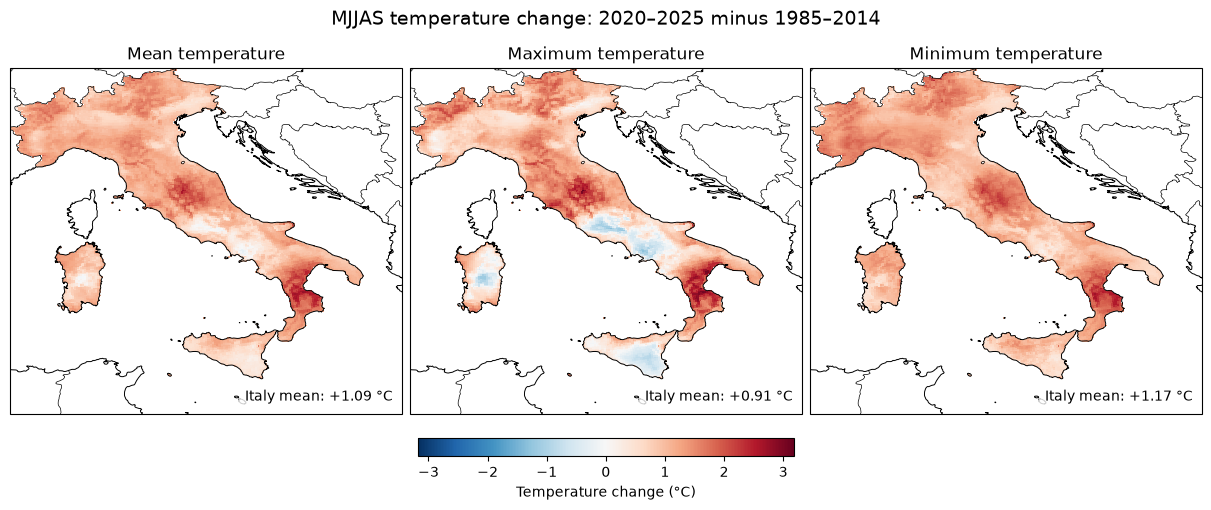

In [64]:
# ============================================================
# Plot MJJAS temperature changes: 2020–2025 minus 1985–2014
# ============================================================

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np


# Remove the singleton height dimension
tmean_change_2d = tmean_change.squeeze(drop=True)
tmax_change_2d  = tmax_change.squeeze(drop=True)
tmin_change_2d  = tmin_change.squeeze(drop=True)


# Fields and labels
fields = [
    tmean_change_2d,
    tmax_change_2d,
    tmin_change_2d
]

titles = [
    "Mean temperature",
    "Maximum temperature",
    "Minimum temperature"
]


# ------------------------------------------------------------
# Common symmetric colour scale
# ------------------------------------------------------------

# Use the largest absolute value across all three fields so that
# the same colour corresponds to the same temperature change
# in every panel.

vmax = max(
    float(np.abs(field).max())
    for field in fields
)

vmin = -vmax


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)


for ax, field, title, italy_mean in zip(axes, fields, titles, italy_means):

    im = ax.pcolormesh(
        lon,
        lat,
        field,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        shading="auto"
    )

    # Coastlines and national borders
    ax.coastlines(resolution="10m", linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # Zoom to the data domain
    ax.set_extent(
        [
            np.nanmin(lon),
            np.nanmax(lon),
            np.nanmin(lat),
            np.nanmax(lat)
        ],
        crs=ccrs.PlateCarree()
    )

     # Print Italy mean change on the map
    ax.text(
        0.60, 0.07,
        f"Italy mean: {italy_mean:+.2f} °C",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.8
        )
    )

    ax.set_title(title)


# ------------------------------------------------------------
# Shared colourbar
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.06
)

cbar.set_label("Temperature change (°C)")

fig.suptitle(
    "MJJAS temperature change: 2020–2025 minus 1985–2014",
    fontsize=14
)

plt.savefig(plots_path / "temp_change_2020-2025_minus_1985-2014.png", dpi=300, bbox_inches='tight')

plt.show()

# 3) Baseline P90 Tmax threshold

In [17]:
# Add day of year to baseline daily maximum temperature (note: we have leapyears so we can't use dayofyear!!!)
tmax_base = tmax_base.assign_coords(
    month_day=("time", tmax_base.time.dt.strftime("%m-%d").values)
)

In [18]:
# 90th percentile of Tmax for each calendar day
# using the 1985–2014 baseline
tmax_p90 = (
    tmax_base
    .groupby("month_day")
    .quantile(0.90, dim="time", skipna=True)
)

c:\Users\ludog\anaconda3\envs\fontanelle\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
c:\Users\ludog\anaconda3\envs\fontanelle\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
c:\Users\ludog\anaconda3\envs\fontanelle\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
c:\Users\ludog\anaconda3\envs\fontanelle\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
c:\Users\ludog\anaconda3\envs\fontanelle\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
c:\Users\ludog\anaconda3\envs\fontanelle\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
c:\Users\ludog\a

In [19]:
tmax_p90 = tmax_p90.squeeze(drop=True)

print(tmax_p90)
print("P90 min:", float(tmax_p90.min()))
print("P90 max:", float(tmax_p90.max()))

<xarray.DataArray '2t' (month_day: 153, y: 229, x: 184)> Size: 26MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ...,

In [20]:
tmax_base = tmax_base.squeeze(drop=True)
tmax_pres = tmax_pres.squeeze(drop=True)

In [21]:
# Create same month_day coordinate for present period
tmax_pres = tmax_pres.assign_coords(
    month_day=("time", tmax_pres.time.dt.strftime("%m-%d").values)
)

In [22]:
# Match each baseline day with its corresponding 1985–2014 P90 threshold
p90_base_daily = tmax_p90.sel(month_day=tmax_base.month_day)

# Match each present-day timestep with the same baseline P90 threshold
p90_pres_daily = tmax_p90.sel(month_day=tmax_pres.month_day)

In [23]:
# Identify days exceeding the local baseline P90 threshold
hot_base = tmax_base > p90_base_daily
hot_pres = tmax_pres > p90_pres_daily

# Define valid Italian land grid cells
land_mask = tmax_base.notnull().any(dim="time")

# Count P90 exceedance days separately for each year
hot_days_base_yearly = hot_base.groupby("time.year").sum(dim="time")
hot_days_pres_yearly = hot_pres.groupby("time.year").sum(dim="time")

# Restore the Italian land mask
hot_days_base_yearly = hot_days_base_yearly.where(land_mask)
hot_days_pres_yearly = hot_days_pres_yearly.where(land_mask)

# Calculate mean number of extreme-hot days per MJJAS season
hot_days_base_mean = hot_days_base_yearly.mean(dim="year")
hot_days_pres_mean = hot_days_pres_yearly.mean(dim="year")

# Calculate recent change relative to baseline
hot_days_change = hot_days_pres_mean - hot_days_base_mean

In [81]:
# Print spatially averaged values as a sanity check
print(f"Baseline: {float(hot_days_base_mean.mean()):.1f} days/season")
print(f"2020–2025: {float(hot_days_pres_mean.mean()):.1f} days/season")
print(f"Change: {float(hot_days_change.mean()):+.1f} days/season")

Baseline: 15.3 days/season
2020–2025: 28.5 days/season
Change: +13.2 days/season


## Plot

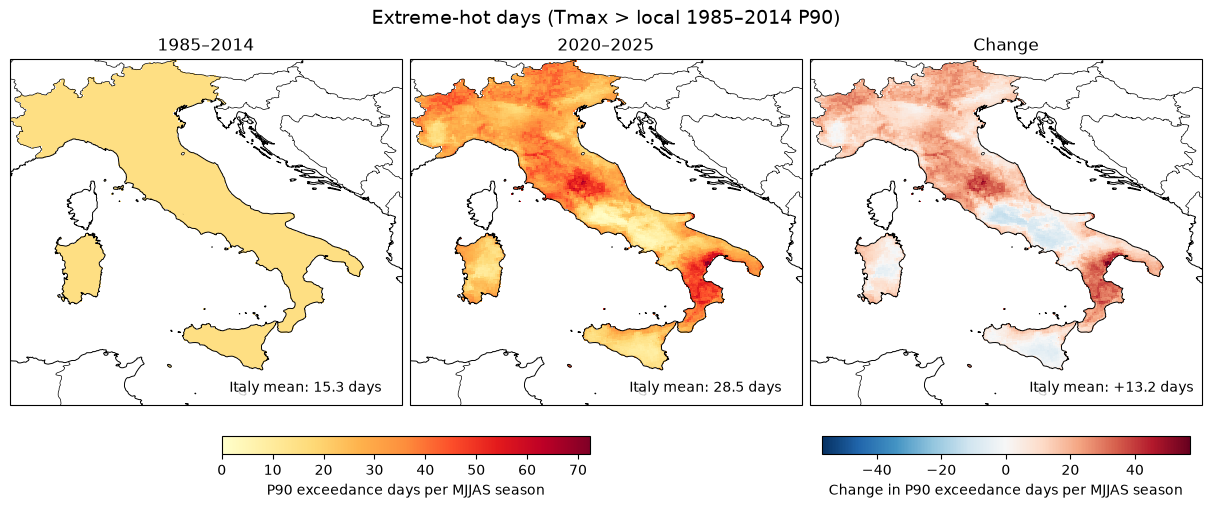

In [87]:
# Import plotting libraries
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Define the three fields to plot
fields = [
    hot_days_base_mean,
    hot_days_pres_mean,
    hot_days_change
]

# Define panel titles
titles = [
    "1985–2014",
    "2020–2025",
    "Change"
]

# Calculate Italy mean values for annotation
italy_means = [
    float(hot_days_base_mean.mean()),
    float(hot_days_pres_mean.mean()),
    float(hot_days_change.mean())
]

# Set common colour scale for baseline and present panels
vmin_main = 0
vmax_main = max(
    float(hot_days_base_mean.max()),
    float(hot_days_pres_mean.max())
)

# Set symmetric colour scale for the change panel
vmax_diff = float(np.abs(hot_days_change).max())
vmin_diff = -vmax_diff

# Create figure with three panels
fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

# Plot baseline field
im0 = axes[0].pcolormesh(
    lon,
    lat,
    hot_days_base_mean,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    vmin=vmin_main,
    vmax=vmax_main,
    shading="auto"
)

# Add map features and text to baseline panel
axes[0].coastlines(resolution="10m", linewidth=0.7)
axes[0].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[0].set_extent(
    [np.nanmin(lon), np.nanmax(lon), np.nanmin(lat), np.nanmax(lat)],
    crs=ccrs.PlateCarree()
)
axes[0].set_title(titles[0])
axes[0].text(
    0.56, 0.07,
    f"Italy mean: {italy_means[0]:.1f} days",
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8)
)

# Plot present field
im1 = axes[1].pcolormesh(
    lon,
    lat,
    hot_days_pres_mean,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    vmin=vmin_main,
    vmax=vmax_main,
    shading="auto"
)

# Add map features and text to present panel
axes[1].coastlines(resolution="10m", linewidth=0.7)
axes[1].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[1].set_extent(
    [np.nanmin(lon), np.nanmax(lon), np.nanmin(lat), np.nanmax(lat)],
    crs=ccrs.PlateCarree()
)
axes[1].set_title(titles[1])
axes[1].text(
    0.56, 0.07,
    f"Italy mean: {italy_means[1]:.1f} days",
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8)
)

# Plot change field
im2 = axes[2].pcolormesh(
    lon,
    lat,
    hot_days_change,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=vmin_diff,
    vmax=vmax_diff,
    shading="auto"
)

# Add map features and text to change panel
axes[2].coastlines(resolution="10m", linewidth=0.7)
axes[2].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[2].set_extent(
    [np.nanmin(lon), np.nanmax(lon), np.nanmin(lat), np.nanmax(lat)],
    crs=ccrs.PlateCarree()
)
axes[2].set_title(titles[2])
axes[2].text(
    0.56, 0.07,
    f"Italy mean: {italy_means[2]:+.1f} days",
    transform=axes[2].transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8)
)

# Add colourbar for baseline and present panels
cbar1 = fig.colorbar(
    im1,
    ax=axes[:2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.08
)
cbar1.set_label("P90 exceedance days per MJJAS season")

# Add colourbar for change panel
cbar2 = fig.colorbar(
    im2,
    ax=axes[2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.08
)
cbar2.set_label("Change in P90 exceedance days per MJJAS season")

# Add overall title
fig.suptitle(
    "Extreme-hot days (Tmax > local 1985–2014 P90)",
    fontsize=14
)

plt.savefig(plots_path / "hot_days_change_2020-2025_minus_1985-2014.png", dpi=300, bbox_inches='tight')
# Show figure
plt.show()

## Check baseline

My guess is that the baseline already has a signal of climate change thus increasing Tmax temperatures towards the latest years, and this might bias the P90 threshold we calculate towards higher temperatures already. 

Quick check of the mean P90 exceedence as Italy-mean in the baseline

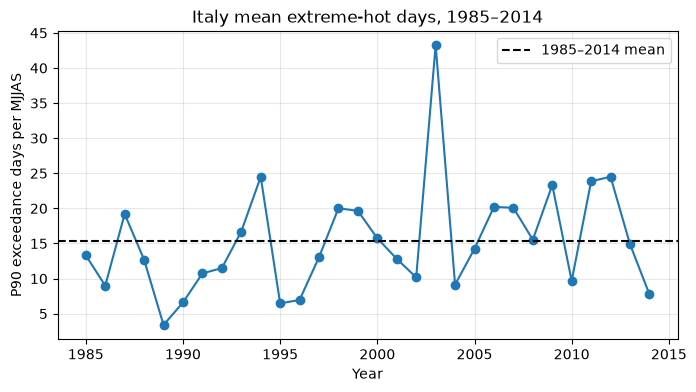

In [28]:
# Calculate Italy-mean number of P90 exceedance days for each year
hot_days_base_italy = hot_days_base_yearly.mean(dim=("y", "x"))

# Plot the annual number of extreme-hot days
plt.figure(figsize=(8, 4))

plt.plot(
    hot_days_base_italy.year,
    hot_days_base_italy,
    marker="o"
)

plt.axhline(
    hot_days_base_italy.mean(),
    color="k",
    linestyle="--",
    label="1985–2014 mean"
)

plt.xlabel("Year")
plt.ylabel("P90 exceedance days per MJJAS")
plt.title("Italy mean extreme-hot days, 1985–2014")

plt.legend()
plt.grid(alpha=0.3)
plt.savefig(plots_path / "hot_days_italy_1985-2014.png", dpi=300, bbox_inches='tight')
plt.show()

# 4) Heatwave detection 

## Daytime heatwave

We define a **daytime** heatwave as:

$T_{max}$ > P90

for at least 3 consecutive days.

In [29]:
# Define a function that identifies all days belonging to runs of at least 3 consecutive hot days
def detect_heatwave_days(hot):

    # Find the third day of every sequence containing at least 3 consecutive P90 exceedances
    three_consecutive = (
        hot.rolling(time=3, min_periods=3).sum() >= 3
    )

    # Extend the mask backwards so the first two days of each heatwave are also included
    heatwave_days = (
        three_consecutive
        | three_consecutive.shift(time=-1, fill_value=False)
        | three_consecutive.shift(time=-2, fill_value=False)
    )

    return heatwave_days

In [30]:
# Detect heatwave days separately within each baseline year
hw_base = hot_base.groupby("time.year").map(detect_heatwave_days)

# Detect heatwave days separately within each present-period year
hw_pres = hot_pres.groupby("time.year").map(detect_heatwave_days)

In [31]:
# Count heatwave days in each MJJAS season
hw_days_base_yearly = hw_base.groupby("time.year").sum(dim="time")
hw_days_pres_yearly = hw_pres.groupby("time.year").sum(dim="time")

# Restore the Italian land mask
hw_days_base_yearly = hw_days_base_yearly.where(land_mask)
hw_days_pres_yearly = hw_days_pres_yearly.where(land_mask)

# Calculate the mean number of heatwave days per MJJAS season
hw_days_base_mean = hw_days_base_yearly.mean(dim="year")
hw_days_pres_mean = hw_days_pres_yearly.mean(dim="year")

# Calculate the 2020–2025 change relative to 1985–2014
hw_days_change = hw_days_pres_mean - hw_days_base_mean

In [32]:
# Print Italy-mean heatwave-day frequency
print(f"Baseline: {float(hw_days_base_mean.mean()):.1f} days/season")
print(f"2020–2025: {float(hw_days_pres_mean.mean()):.1f} days/season")
print(f"Change: {float(hw_days_change.mean()):+.1f} days/season")

Baseline: 9.0 days/season
2020–2025: 18.9 days/season
Change: +9.9 days/season


In [33]:
# Heatwave days must always be fewer than or equal to total P90 exceedance days
print(
    "Baseline hot days:",
    float(hot_days_base_mean.mean()),
    "Heatwave days:",
    float(hw_days_base_mean.mean())
)

Baseline hot days: 15.299888087949705 Heatwave days: 8.979901912379447


In [34]:
# Identify the first day of each heatwave event
def detect_hw_starts(hw):
    return hw & ~hw.shift(time=1, fill_value=False)

# Identify heatwave starts separately within each year
hw_starts_base = hw_base.groupby("time.year").map(detect_hw_starts)
hw_starts_pres = hw_pres.groupby("time.year").map(detect_hw_starts)

# Count heatwave events per year
hw_events_base_yearly = hw_starts_base.groupby("time.year").sum(dim="time")
hw_events_pres_yearly = hw_starts_pres.groupby("time.year").sum(dim="time")

# Restore the Italian land mask
hw_events_base_yearly = hw_events_base_yearly.where(land_mask)
hw_events_pres_yearly = hw_events_pres_yearly.where(land_mask)

# Calculate mean number of heatwave events per season
hw_events_base_mean = hw_events_base_yearly.mean(dim="year")
hw_events_pres_mean = hw_events_pres_yearly.mean(dim="year")

# Calculate change in heatwave frequency
hw_events_change = hw_events_pres_mean - hw_events_base_mean

In [35]:
# Calculate mean heatwave duration for every year
hw_duration_base_yearly = (
    hw_days_base_yearly / hw_events_base_yearly
).where(hw_events_base_yearly > 0)

hw_duration_pres_yearly = (
    hw_days_pres_yearly / hw_events_pres_yearly
).where(hw_events_pres_yearly > 0)

# Calculate climatological mean heatwave duration
hw_duration_base_mean = hw_duration_base_yearly.mean(dim="year")
hw_duration_pres_mean = hw_duration_pres_yearly.mean(dim="year")

# Calculate change in mean heatwave duration
hw_duration_change = hw_duration_pres_mean - hw_duration_base_mean

In [36]:
# Calculate Tmax exceedance above the local P90 threshold
hw_excess_base = (tmax_base - p90_base_daily).where(hw_base)
hw_excess_pres = (tmax_pres - p90_pres_daily).where(hw_pres)

# Calculate mean heatwave intensity for each year
hw_intensity_base_yearly = hw_excess_base.groupby("time.year").mean(dim="time")
hw_intensity_pres_yearly = hw_excess_pres.groupby("time.year").mean(dim="time")

# Calculate mean heatwave intensity for each period
hw_intensity_base_mean = hw_intensity_base_yearly.mean(dim="year")
hw_intensity_pres_mean = hw_intensity_pres_yearly.mean(dim="year")

# Calculate change in heatwave intensity
hw_intensity_change = hw_intensity_pres_mean - hw_intensity_base_mean

In [38]:
# Calculate Italy-mean values for each heatwave metric
hw_days_base_it = float(hw_days_base_mean.mean())
hw_days_pres_it = float(hw_days_pres_mean.mean())

hw_events_base_it = float(hw_events_base_mean.mean())
hw_events_pres_it = float(hw_events_pres_mean.mean())

hw_duration_base_it = float(hw_duration_base_mean.mean())
hw_duration_pres_it = float(hw_duration_pres_mean.mean())

hw_intensity_base_it = float(hw_intensity_base_mean.mean())
hw_intensity_pres_it = float(hw_intensity_pres_mean.mean())


# Calculate percentage changes relative to the baseline
hw_days_pct = (hw_days_pres_it - hw_days_base_it) / hw_days_base_it * 100
hw_events_pct = (hw_events_pres_it - hw_events_base_it) / hw_events_base_it * 100
hw_duration_pct = (hw_duration_pres_it - hw_duration_base_it) / hw_duration_base_it * 100
hw_intensity_pct = (hw_intensity_pres_it - hw_intensity_base_it) / hw_intensity_base_it * 100


# Print Italy-mean heatwave statistics
print(
    f"Heatwave days: "
    f"{hw_days_base_it:.1f} → {hw_days_pres_it:.1f} "
    f"({hw_days_pres_it - hw_days_base_it:+.1f} days, "
    f"{hw_days_pct:+.1f}%)"
)

print(
    f"Heatwave events: "
    f"{hw_events_base_it:.2f} → {hw_events_pres_it:.2f} "
    f"({hw_events_pres_it - hw_events_base_it:+.2f} events, "
    f"{hw_events_pct:+.1f}%)"
)

print(
    f"Mean duration: "
    f"{hw_duration_base_it:.2f} → {hw_duration_pres_it:.2f} "
    f"({hw_duration_pres_it - hw_duration_base_it:+.2f} days, "
    f"{hw_duration_pct:+.1f}%)"
)

print(
    f"Intensity: "
    f"{hw_intensity_base_it:.2f} → {hw_intensity_pres_it:.2f} "
    f"({hw_intensity_pres_it - hw_intensity_base_it:+.2f} °C, "
    f"{hw_intensity_pct:+.1f}%)"
)

Heatwave days: 9.0 → 18.9 (+9.9 days, +110.0%)
Heatwave events: 1.92 → 3.72 (+1.80 events, +93.9%)
Mean duration: 4.59 → 4.94 (+0.35 days, +7.5%)
Intensity: 1.90 → 2.00 (+0.10 °C, +5.2%)


### Plot

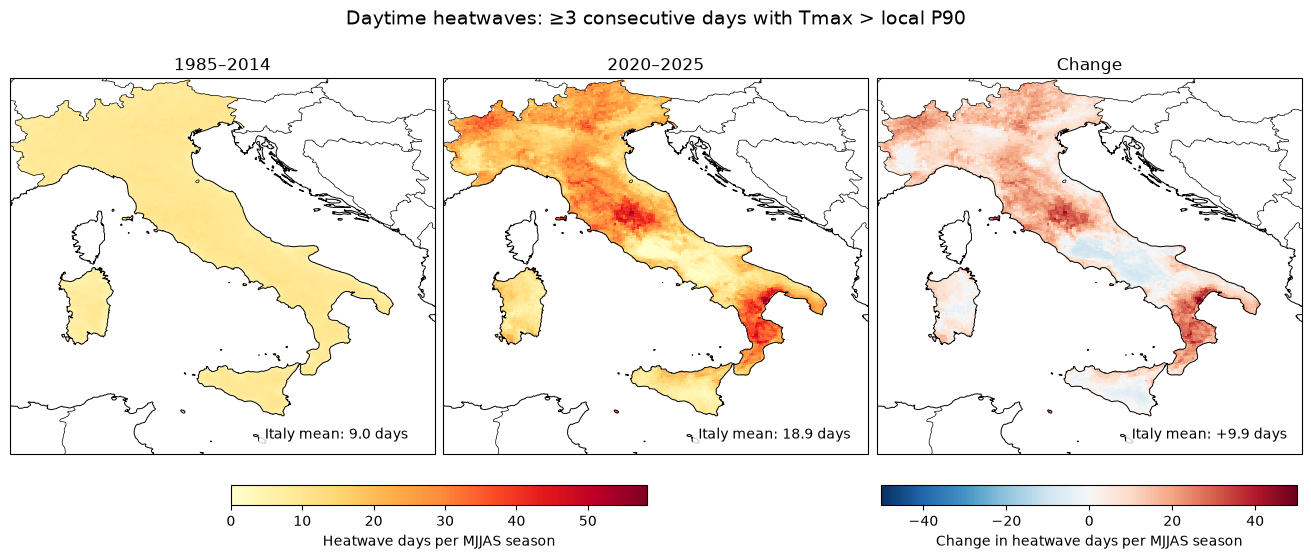

In [48]:
# Define heatwave-day fields and Italy means
hw_fields = [
    hw_days_base_mean,
    hw_days_pres_mean,
    hw_days_change
]

hw_titles = [
    "1985–2014",
    "2020–2025",
    "Change"
]

hw_italy_means = [
    float(hw_days_base_mean.mean()),
    float(hw_days_pres_mean.mean()),
    float(hw_days_change.mean())
]

# Use the same scale for baseline and present heatwave days
vmax_main = max(
    float(hw_days_base_mean.max()),
    float(hw_days_pres_mean.max())
)

# Use a symmetric scale around zero for the change
vmax_change = float(np.abs(hw_days_change).max())

# Create the figure
fig, axes = plt.subplots(
    1, 3,
    figsize=(13, 5.5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

# Plot baseline heatwave days
im0 = axes[0].pcolormesh(
    lon, lat, hw_days_base_mean,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    vmin=0,
    vmax=vmax_main,
    shading="auto"
)

# Plot present heatwave days
im1 = axes[1].pcolormesh(
    lon, lat, hw_days_pres_mean,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    vmin=0,
    vmax=vmax_main,
    shading="auto"
)

# Plot change in heatwave days
im2 = axes[2].pcolormesh(
    lon, lat, hw_days_change,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-vmax_change,
    vmax=vmax_change,
    shading="auto"
)

# Add common map formatting
for ax, title, mean_value in zip(
    axes,
    hw_titles,
    hw_italy_means
):
    ax.coastlines(resolution="10m", linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    ax.set_extent(
        [
            np.nanmin(lon),
            np.nanmax(lon),
            np.nanmin(lat),
            np.nanmax(lat)
        ],
        crs=ccrs.PlateCarree()
    )

    ax.set_title(title)

    ax.text(
        0.60, 0.07,
        f"Italy mean: {mean_value:+.1f} days"
        if title == "Change"
        else f"Italy mean: {mean_value:.1f} days",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.8
        )
    )

# Add colourbar for absolute heatwave days
cbar1 = fig.colorbar(
    im1,
    ax=axes[:2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.07
)
cbar1.set_label("Heatwave days per MJJAS season")

# Add separate colourbar for change
cbar2 = fig.colorbar(
    im2,
    ax=axes[2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.07
)
cbar2.set_label("Change in heatwave days per MJJAS season")

# Add figure title
fig.suptitle(
    "Daytime heatwaves: ≥3 consecutive days with Tmax > local P90",
    fontsize=14
)

plt.savefig(plots_path / "daytime_heatwave_days_change_2020-2025_minus_1985-2014.png", dpi=300, bbox_inches='tight')

plt.show()

## Tropical nights

We define a tropical night as: 

$T_{min} > 20°C$

In [49]:
# Remove the singleton height dimension
tmin_base = tmin_base.squeeze(drop=True)
tmin_pres = tmin_pres.squeeze(drop=True)

# Identify tropical nights (Tmin >= 20 °C)
tn_base = tmin_base >= 20
tn_pres = tmin_pres >= 20

# Count tropical nights separately for each year
tn_base_yearly = tn_base.groupby("time.year").sum(dim="time")
tn_pres_yearly = tn_pres.groupby("time.year").sum(dim="time")

# Restore the Italian land mask
tn_base_yearly = tn_base_yearly.where(land_mask)
tn_pres_yearly = tn_pres_yearly.where(land_mask)

# Calculate mean tropical nights per MJJAS season
tn_base_mean = tn_base_yearly.mean(dim="year")
tn_pres_mean = tn_pres_yearly.mean(dim="year")

# Calculate present-day change relative to baseline
tn_change = tn_pres_mean - tn_base_mean

In [50]:
# Calculate Italy-mean tropical-night statistics
tn_base_it = float(tn_base_mean.mean())
tn_pres_it = float(tn_pres_mean.mean())
tn_change_it = float(tn_change.mean())

# Calculate percentage change relative to baseline
tn_pct = (tn_pres_it - tn_base_it) / tn_base_it * 100

# Print Italy-mean tropical-night statistics
print(
    f"Tropical nights: "
    f"{tn_base_it:.1f} → {tn_pres_it:.1f} "
    f"({tn_change_it:+.1f} nights, "
    f"{tn_pct:+.1f}%)"
)

Tropical nights: 24.8 → 36.8 (+12.0 nights, +48.4%)


### Plot

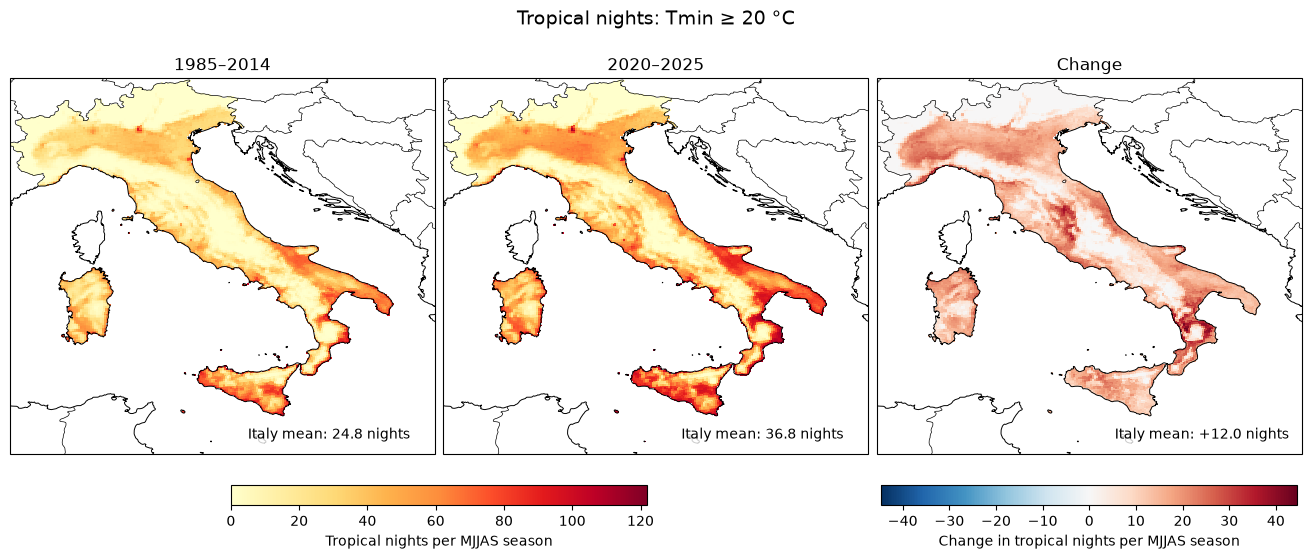

In [56]:
# Define tropical-night fields and Italy means
tn_fields = [
    tn_base_mean,
    tn_pres_mean,
    tn_change
]

tn_titles = [
    "1985–2014",
    "2020–2025",
    "Change"
]

tn_italy_means = [
    float(tn_base_mean.mean()),
    float(tn_pres_mean.mean()),
    float(tn_change.mean())
]

# Calculate Italy-wide percentage change in tropical nights
tn_pct = (
    (tn_italy_means[1] - tn_italy_means[0]) / tn_italy_means[0]
) * 100

# Use the same scale for baseline and present
vmax_main = max(
    float(tn_base_mean.max()),
    float(tn_pres_mean.max())
)

# Use a symmetric scale around zero for the change
vmax_change = float(np.abs(tn_change).max())

# Create the figure
fig, axes = plt.subplots(
    1, 3,
    figsize=(13, 5.5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

# Plot baseline tropical nights
im0 = axes[0].pcolormesh(
    lon, lat, tn_base_mean,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    vmin=0,
    vmax=vmax_main,
    shading="auto"
)

# Plot present tropical nights
im1 = axes[1].pcolormesh(
    lon, lat, tn_pres_mean,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    vmin=0,
    vmax=vmax_main,
    shading="auto"
)

# Plot change in tropical nights
im2 = axes[2].pcolormesh(
    lon, lat, tn_change,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-vmax_change,
    vmax=vmax_change,
    shading="auto"
)

# Add common map formatting
for ax, title, mean_value in zip(
    axes,
    tn_titles,
    tn_italy_means
):
    ax.coastlines(resolution="10m", linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    ax.set_extent(
        [
            np.nanmin(lon),
            np.nanmax(lon),
            np.nanmin(lat),
            np.nanmax(lat)
        ],
        crs=ccrs.PlateCarree()
    )

    ax.set_title(title)

    # Add Italy-mean values
  
    textstr = f"Italy mean: {mean_value:+.1f} nights" if title == "Change" else f"Italy mean: {mean_value:.1f} nights"

    ax.text(
        0.56, 0.07,
        textstr,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.8
        )
    )

# Add colourbar for baseline and present
cbar1 = fig.colorbar(
    im1,
    ax=axes[:2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.07
)
cbar1.set_label("Tropical nights per MJJAS season")

# Add separate colourbar for change
cbar2 = fig.colorbar(
    im2,
    ax=axes[2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.07
)
cbar2.set_label("Change in tropical nights per MJJAS season")

# Add figure title
fig.suptitle(
    "Tropical nights: Tmin ≥ 20 °C",
    fontsize=14
)

plt.savefig(plots_path / "tropical_nights_change_2020-2025_minus_1985-2014.png", dpi=300, bbox_inches='tight')

plt.show()

## Compund day-night heatwaves

We define a compound day-night heatwave as: 

$T_{max} > P90$ and $T_{min} > P90$

For at least 3 consecutive days

In [58]:
# Add calendar-day coordinate to Tmin baseline
tmin_base = tmin_base.assign_coords(
    month_day=("time", tmin_base.time.dt.strftime("%m-%d").values)
)

# Calculate local calendar-day P90 threshold for Tmin
tmin_p90 = (
        tmin_base
        .groupby("month_day")
        .quantile(0.90, dim="time", skipna=True)
        .squeeze(drop=True)
    )

c:\Users\ludog\anaconda3\envs\fontanelle\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
c:\Users\ludog\anaconda3\envs\fontanelle\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
c:\Users\ludog\anaconda3\envs\fontanelle\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
c:\Users\ludog\anaconda3\envs\fontanelle\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
c:\Users\ludog\anaconda3\envs\fontanelle\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
c:\Users\ludog\anaconda3\envs\fontanelle\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
c:\Users\ludog\a

In [59]:
# Add calendar-day coordinate to present Tmin
tmin_pres = tmin_pres.assign_coords(
    month_day=("time", tmin_pres.time.dt.strftime("%m-%d").values)
)

In [60]:
# Match baseline days with their corresponding P90 thresholds
tmax_p90_base_daily = tmax_p90.sel(month_day=tmax_base.month_day)
tmin_p90_base_daily = tmin_p90.sel(month_day=tmin_base.month_day)

# Match present days with the same baseline P90 thresholds
tmax_p90_pres_daily = tmax_p90.sel(month_day=tmax_pres.month_day)
tmin_p90_pres_daily = tmin_p90.sel(month_day=tmin_pres.month_day)

In [61]:
# Identify days when both Tmax and Tmin exceed their local baseline P90
compound_hot_base = (
    (tmax_base > tmax_p90_base_daily)
    & (tmin_base > tmin_p90_base_daily)
)

compound_hot_pres = (
    (tmax_pres > tmax_p90_pres_daily)
    & (tmin_pres > tmin_p90_pres_daily)
)

In [62]:
# Detect compound heatwave days separately within each year
compound_hw_base = compound_hot_base.groupby("time.year").map(
    detect_heatwave_days
)

compound_hw_pres = compound_hot_pres.groupby("time.year").map(
    detect_heatwave_days
)

In [63]:
# Count compound heatwave days in each MJJAS season
compound_hw_days_base_yearly = (
    compound_hw_base.groupby("time.year").sum(dim="time")
)

compound_hw_days_pres_yearly = (
    compound_hw_pres.groupby("time.year").sum(dim="time")
)

# Restore the Italian land mask
compound_hw_days_base_yearly = compound_hw_days_base_yearly.where(land_mask)
compound_hw_days_pres_yearly = compound_hw_days_pres_yearly.where(land_mask)

# Calculate mean compound heatwave days per season
compound_hw_days_base_mean = compound_hw_days_base_yearly.mean(dim="year")
compound_hw_days_pres_mean = compound_hw_days_pres_yearly.mean(dim="year")

# Calculate recent change relative to the baseline
compound_hw_days_change = (
    compound_hw_days_pres_mean - compound_hw_days_base_mean
)

In [64]:
# Calculate Italy-mean compound heatwave statistics
compound_base_it = float(compound_hw_days_base_mean.mean())
compound_pres_it = float(compound_hw_days_pres_mean.mean())
compound_change_it = float(compound_hw_days_change.mean())

# Calculate percentage change relative to baseline
compound_pct = (
    (compound_pres_it - compound_base_it) / compound_base_it * 100
)

# Print Italy-mean results
print(
    f"Compound heatwave days: "
    f"{compound_base_it:.2f} → {compound_pres_it:.2f} "
    f"({compound_change_it:+.2f} days, "
    f"{compound_pct:+.1f}%)"
)

Compound heatwave days: 3.77 → 10.68 (+6.91 days, +183.3%)


In [ ]:
# Detect duration of events
# Identify the first day of each compound heatwave
def detect_hw_starts(hw):
    return hw & ~hw.shift(time=1, fill_value=False)

# Detect compound heatwave starts separately within each year
compound_starts_base = compound_hw_base.groupby("time.year").map(
    detect_hw_starts
)

compound_starts_pres = compound_hw_pres.groupby("time.year").map(
    detect_hw_starts
)

# Count compound heatwave events per MJJAS season
compound_events_base_yearly = (
    compound_starts_base.groupby("time.year").sum(dim="time")
)

compound_events_pres_yearly = (
    compound_starts_pres.groupby("time.year").sum(dim="time")
)

# Restore the Italian land mask
compound_events_base_yearly = compound_events_base_yearly.where(land_mask)
compound_events_pres_yearly = compound_events_pres_yearly.where(land_mask)

In [67]:
# Calculate mean compound heatwave duration for each year
compound_duration_base_yearly = (
    compound_hw_days_base_yearly / compound_events_base_yearly
).where(compound_events_base_yearly > 0)

compound_duration_pres_yearly = (
    compound_hw_days_pres_yearly / compound_events_pres_yearly
).where(compound_events_pres_yearly > 0)

# Calculate mean duration for each period
compound_duration_base_mean = compound_duration_base_yearly.mean(dim="year")
compound_duration_pres_mean = compound_duration_pres_yearly.mean(dim="year")

# Calculate recent change in mean duration
compound_duration_change = (
    compound_duration_pres_mean - compound_duration_base_mean
)

In [68]:
# Print Italy-mean compound heatwave duration
print(
    f"Mean duration: "
    f"{float(compound_duration_base_mean.mean()):.2f} → "
    f"{float(compound_duration_pres_mean.mean()):.2f} days "
    f"({float(compound_duration_change.mean()):+.2f} days)"
)

Mean duration: 4.19 → 4.60 days (+0.42 days)


In [ ]:
# Max duration of the events (might be more interesting that the mean duration especially for vulnerability studies)

# Return the length of the longest consecutive True sequence
def longest_run(values):
    longest = 0
    current = 0

    for value in values:
        if value:
            current += 1
            longest = max(longest, current)
        else:
            current = 0

    return longest

In [72]:
# Calculate longest compound heatwave for each year
compound_max_duration_base_yearly = compound_hw_base.groupby(
    "time.year"
).map(
    lambda x: xr.apply_ufunc(
        longest_run,
        x,
        input_core_dims=[["time"]],
        vectorize=True,
        output_dtypes=[int]
    )
)

compound_max_duration_pres_yearly = compound_hw_pres.groupby(
    "time.year"
).map(
    lambda x: xr.apply_ufunc(
        longest_run,
        x,
        input_core_dims=[["time"]],
        vectorize=True,
        output_dtypes=[int]
    )
)

# Restore the Italian land mask
compound_max_duration_base_yearly = (
    compound_max_duration_base_yearly.where(land_mask)
)

compound_max_duration_pres_yearly = (
    compound_max_duration_pres_yearly.where(land_mask)
)

# Calculate mean seasonal maximum duration
compound_max_duration_base_mean = (
    compound_max_duration_base_yearly.mean(dim="year")
)

compound_max_duration_pres_mean = (
    compound_max_duration_pres_yearly.mean(dim="year")
)

# Calculate recent change
compound_max_duration_change = (
    compound_max_duration_pres_mean
    - compound_max_duration_base_mean
)

In [73]:
# Print Italy-mean maximum compound heatwave duration
print(
    f"Maximum duration: "
    f"{float(compound_max_duration_base_mean.mean()):.2f} → "
    f"{float(compound_max_duration_pres_mean.mean()):.2f} days "
    f"({float(compound_max_duration_change.mean()):+.2f} days)"
)

Maximum duration: 2.31 → 5.17 days (+2.86 days)


### Plot

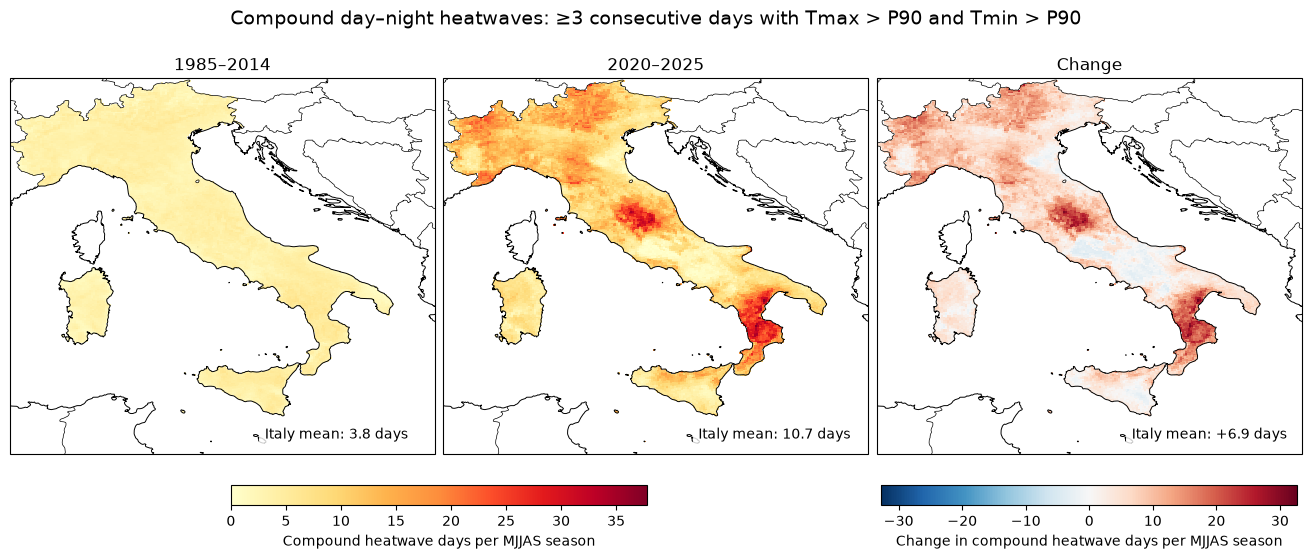

In [75]:
# Define compound heatwave fields and Italy means
compound_fields = [
    compound_hw_days_base_mean,
    compound_hw_days_pres_mean,
    compound_hw_days_change
]

compound_titles = [
    "1985–2014",
    "2020–2025",
    "Change"
]

compound_italy_means = [
    float(compound_hw_days_base_mean.mean()),
    float(compound_hw_days_pres_mean.mean()),
    float(compound_hw_days_change.mean())
]

# Use the same scale for baseline and present
vmax_main = max(
    float(compound_hw_days_base_mean.max()),
    float(compound_hw_days_pres_mean.max())
)

# Use a symmetric scale around zero for the change
vmax_change = float(np.abs(compound_hw_days_change).max())

# Create the figure
fig, axes = plt.subplots(
    1, 3,
    figsize=(13, 5.5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

# Plot baseline compound heatwave days
im0 = axes[0].pcolormesh(
    lon, lat, compound_hw_days_base_mean,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    vmin=0,
    vmax=vmax_main,
    shading="auto"
)

# Plot present compound heatwave days
im1 = axes[1].pcolormesh(
    lon, lat, compound_hw_days_pres_mean,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    vmin=0,
    vmax=vmax_main,
    shading="auto"
)

# Plot change in compound heatwave days
im2 = axes[2].pcolormesh(
    lon, lat, compound_hw_days_change,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-vmax_change,
    vmax=vmax_change,
    shading="auto"
)

# Add common map formatting
for ax, title, mean_value in zip(
    axes,
    compound_titles,
    compound_italy_means
):
    ax.coastlines(resolution="10m", linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    ax.set_extent(
        [
            np.nanmin(lon),
            np.nanmax(lon),
            np.nanmin(lat),
            np.nanmax(lat)
        ],
        crs=ccrs.PlateCarree()
    )

    ax.set_title(title)

    # Add Italy-mean values
    if title == "Change":
        textstr = f"Italy mean: {mean_value:+.1f} days"
    else:
        textstr = f"Italy mean: {mean_value:.1f} days"

    ax.text(
        0.60, 0.07,
        textstr,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.8
        )
    )

# Add colourbar for baseline and present
cbar1 = fig.colorbar(
    im1,
    ax=axes[:2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.07
)
cbar1.set_label("Compound heatwave days per MJJAS season")

# Add separate colourbar for change
cbar2 = fig.colorbar(
    im2,
    ax=axes[2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.07
)
cbar2.set_label("Change in compound heatwave days per MJJAS season")

# Add figure title
fig.suptitle(
    "Compound day–night heatwaves: ≥3 consecutive days with "
    "Tmax > P90 and Tmin > P90",
    fontsize=14
)

plt.savefig(
    plots_path / "compound_heatwave_days_change_2020-2025_minus_1985-2014.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

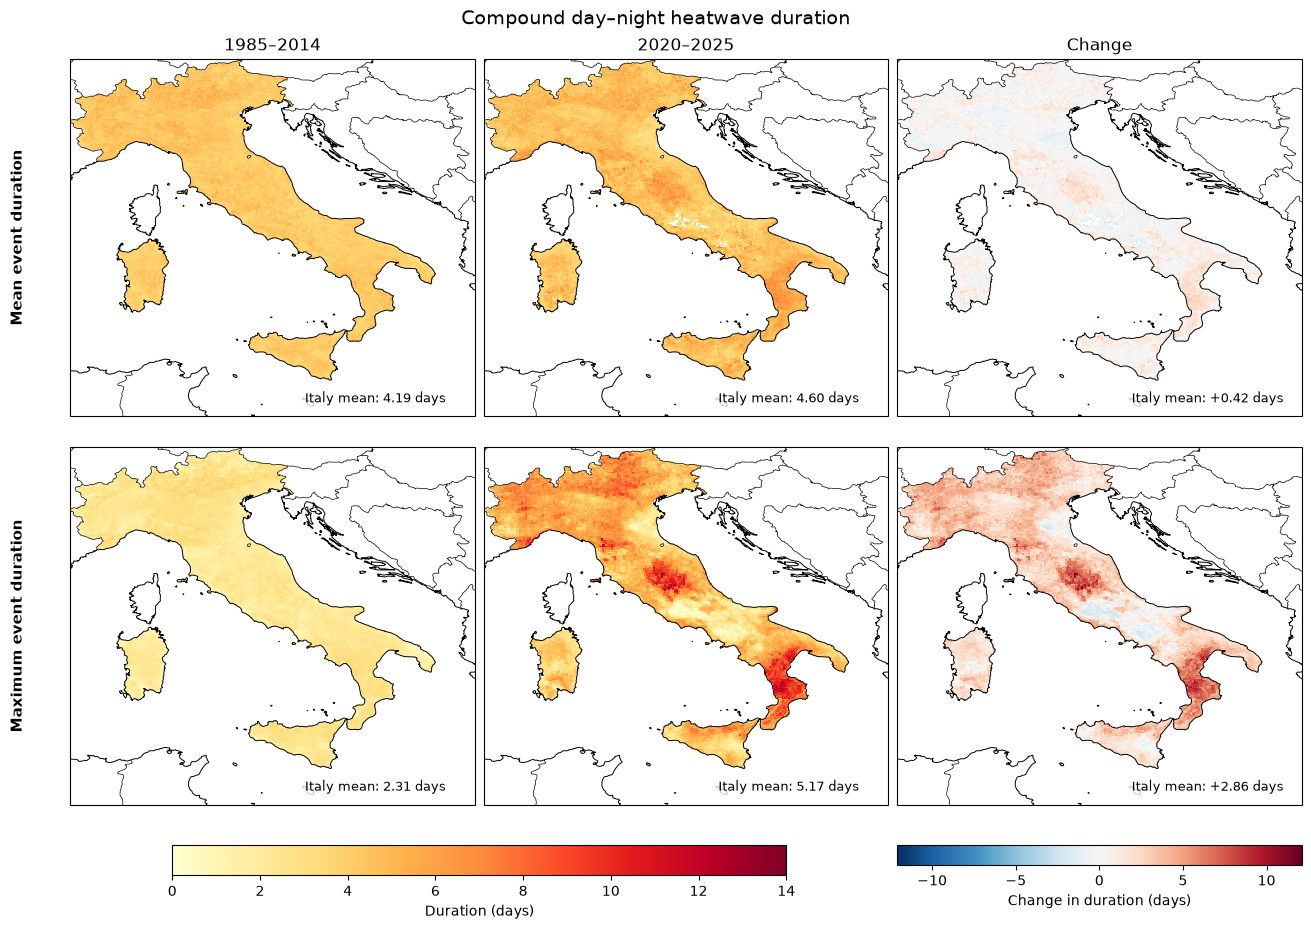

In [79]:
# Define duration fields
duration_grid = [
    [
        compound_duration_base_mean,
        compound_duration_pres_mean,
        compound_duration_change
    ],
    [
        compound_max_duration_base_mean,
        compound_max_duration_pres_mean,
        compound_max_duration_change
    ]
]

# Define column and row titles
col_titles = [
    "1985–2014",
    "2020–2025",
    "Change"
]

row_titles = [
    "Mean event duration",
    "Maximum event duration"
]

# Calculate Italy-mean values
duration_italy_means = [
    [
        float(compound_duration_base_mean.mean()),
        float(compound_duration_pres_mean.mean()),
        float(compound_duration_change.mean())
    ],
    [
        float(compound_max_duration_base_mean.mean()),
        float(compound_max_duration_pres_mean.mean()),
        float(compound_max_duration_change.mean())
    ]
]

# Use one absolute scale for all baseline and present panels
vmax_main = max(
    float(compound_duration_base_mean.max()),
    float(compound_duration_pres_mean.max()),
    float(compound_max_duration_base_mean.max()),
    float(compound_max_duration_pres_mean.max())
)

# Use one symmetric scale for both change panels
vmax_change = max(
    float(np.abs(compound_duration_change).max()),
    float(np.abs(compound_max_duration_change).max())
)

# Create figure
fig, axes = plt.subplots(
    2, 3,
    figsize=(13, 9.2),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

# Plot all duration fields
for i in range(2):
    for j in range(3):

        ax = axes[i, j]
        field = duration_grid[i][j]
        mean_value = duration_italy_means[i][j]

        # Plot baseline and present with sequential scale
        if j < 2:
            im_main = ax.pcolormesh(
                lon,
                lat,
                field,
                transform=ccrs.PlateCarree(),
                cmap="YlOrRd",
                vmin=0,
                vmax=vmax_main,
                shading="auto"
            )

        # Plot change with diverging scale
        else:
            im_change = ax.pcolormesh(
                lon,
                lat,
                field,
                transform=ccrs.PlateCarree(),
                cmap="RdBu_r",
                vmin=-vmax_change,
                vmax=vmax_change,
                shading="auto"
            )

        # Add map features
        ax.coastlines(resolution="10m", linewidth=0.7)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        # Set map extent
        ax.set_extent(
            [
                np.nanmin(lon),
                np.nanmax(lon),
                np.nanmin(lat),
                np.nanmax(lat)
            ],
            crs=ccrs.PlateCarree()
        )

        # Add column titles
        if i == 0:
            ax.set_title(col_titles[j])

        # Add Italy-mean annotation
        ax.text(
            0.58, 0.07,
            f"Italy mean: {mean_value:+.2f} days"
            if j == 2
            else f"Italy mean: {mean_value:.2f} days",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.8
            )
        )

# Add row labels
for i, label in enumerate(row_titles):
    axes[i, 0].text(
        -0.13, 0.5,
        label,
        transform=axes[i, 0].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# Add colourbar for absolute duration
cbar1 = fig.colorbar(
    im_main,
    ax=axes[:, :2],
    orientation="horizontal",
    fraction=0.04,
    pad=0.05
)
cbar1.set_label("Duration (days)")

# Add colourbar for duration change
cbar2 = fig.colorbar(
    im_change,
    ax=axes[:, 2],
    orientation="horizontal",
    fraction=0.04,
    pad=0.05
)
cbar2.set_label("Change in duration (days)")

# Add figure title
fig.suptitle(
    "Compound day–night heatwave duration",
    fontsize=14
)

plt.savefig(
    plots_path / "compound_heatwave_duration_change_2020-2025_minus_1985-2014.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# EXTRA: Baseline sensitivity check

Check climate change signal in the abseline period to test whether it's already affecting the P90 thresholds

In [80]:
# Calculate mean MJJAS Tmax for each year
tmax_base_yearly = tmax_base.groupby("time.year").mean(dim="time")

# Calculate the Italy mean for each year
tmax_base_italy_yearly = tmax_base_yearly.mean(dim=("y", "x"))

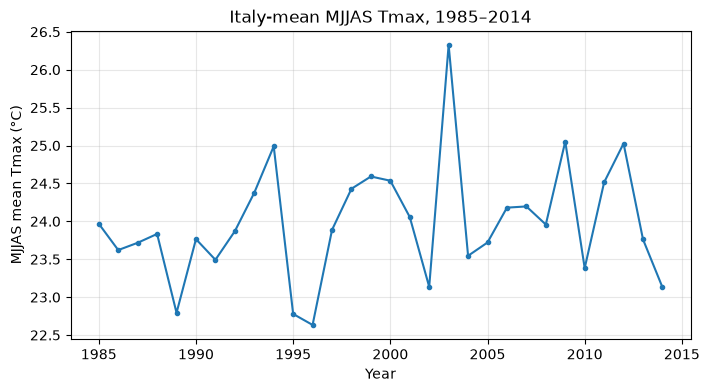

In [81]:
# Plot yearly Italy-mean MJJAS Tmax
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    tmax_base_italy_yearly.year,
    tmax_base_italy_yearly,
    marker="o",
    markersize=3
)

ax.set_xlabel("Year")
ax.set_ylabel("MJJAS mean Tmax (°C)")
ax.set_title("Italy-mean MJJAS Tmax, 1985–2014")

ax.grid(alpha=0.3)

plt.show()

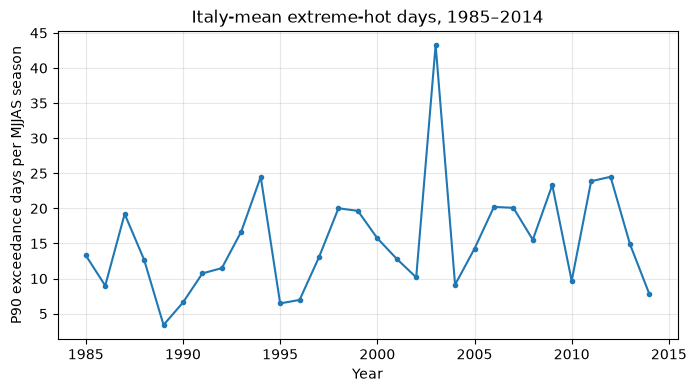

In [82]:
# Calculate Italy-mean P90 exceedance days for each baseline year
hot_days_base_italy = hot_days_base_yearly.mean(dim=("y", "x"))

# Plot yearly P90 exceedance days
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    hot_days_base_italy.year,
    hot_days_base_italy,
    marker="o",
    markersize=3
)

ax.set_xlabel("Year")
ax.set_ylabel("P90 exceedance days per MJJAS season")
ax.set_title("Italy-mean extreme-hot days, 1985–2014")

ax.grid(alpha=0.3)

plt.show()

## Test 1985-1999 vs 2000-2014

In [83]:
# Split the baseline into two 15-year periods
tmax_early = tmax_base.sel(time=slice("1985", "1999"))
tmax_late  = tmax_base.sel(time=slice("2000", "2014"))

# Calculate mean MJJAS Tmax for each period
tmax_early_mean = tmax_early.mean(dim="time")
tmax_late_mean  = tmax_late.mean(dim="time")

# Calculate late minus early Tmax change
tmax_baseline_change = tmax_late_mean - tmax_early_mean

In [84]:
# Print Italy-mean warming between the two baseline halves
print(
    f"1985–1999: {float(tmax_early_mean.mean()):.2f} °C"
)

print(
    f"2000–2014: {float(tmax_late_mean.mean()):.2f} °C"
)

print(
    f"Change: {float(tmax_baseline_change.mean()):+.2f} °C"
)

1985–1999: 23.78 °C
2000–2014: 24.17 °C
Change: +0.39 °C


### Sensitivity of P90 threshold

In [88]:
# Calculate calendar-day P90 using the early baseline
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="All-NaN slice encountered",
        category=RuntimeWarning
    )

    tmax_p90_early = (
        tmax_early
        .groupby("month_day")
        .quantile(0.90, dim="time", skipna=True)
        .squeeze(drop=True)
    )

# Calculate calendar-day P90 using the late baseline
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="All-NaN slice encountered",
        category=RuntimeWarning
    )

    tmax_p90_late = (
        tmax_late
        .groupby("month_day")
        .quantile(0.90, dim="time", skipna=True)
        .squeeze(drop=True)
    )

In [89]:
# Calculate the change in P90 threshold between the two baseline halves
p90_baseline_change = (
    tmax_p90_late.mean(dim="month_day")
    - tmax_p90_early.mean(dim="month_day")
)

# Print Italy-mean P90 threshold change
print(
    f"Mean P90 threshold change: "
    f"{float(p90_baseline_change.mean()):+.2f} °C"
)

Mean P90 threshold change: +0.53 °C


In [90]:
# Apply both thresholds to the present period

# Match each present day with the early-baseline P90 threshold
p90_early_pres_daily = tmax_p90_early.sel(
    month_day=tmax_pres.month_day
)

# Match each present day with the late-baseline P90 threshold
p90_late_pres_daily = tmax_p90_late.sel(
    month_day=tmax_pres.month_day
)

# Identify recent hot days using the early threshold
hot_pres_early = tmax_pres > p90_early_pres_daily

# Identify recent hot days using the late threshold
hot_pres_late = tmax_pres > p90_late_pres_daily

In [91]:
# Count recent P90 exceedance days using each threshold
hot_days_pres_early_yearly = (
    hot_pres_early.groupby("time.year").sum(dim="time")
)

hot_days_pres_late_yearly = (
    hot_pres_late.groupby("time.year").sum(dim="time")
)

# Restore the Italian land mask
hot_days_pres_early_yearly = hot_days_pres_early_yearly.where(land_mask)
hot_days_pres_late_yearly = hot_days_pres_late_yearly.where(land_mask)

# Calculate mean number of hot days per MJJAS season
hot_days_pres_early_mean = hot_days_pres_early_yearly.mean(dim="year")
hot_days_pres_late_mean = hot_days_pres_late_yearly.mean(dim="year")

# Calculate sensitivity to the reference period
hot_days_threshold_difference = (
    hot_days_pres_late_mean - hot_days_pres_early_mean
)

In [92]:
# Print Italy-mean sensitivity of recent hot-day frequency
print(
    f"2020–2025 hot days using 1985–1999 P90: "
    f"{float(hot_days_pres_early_mean.mean()):.1f} days/season"
)

print(
    f"2020–2025 hot days using 2000–2014 P90: "
    f"{float(hot_days_pres_late_mean.mean()):.1f} days/season"
)

print(
    f"Difference caused by threshold choice: "
    f"{float(hot_days_threshold_difference.mean()):+.1f} days/season"
)

2020–2025 hot days using 1985–1999 P90: 39.1 days/season
2020–2025 hot days using 2000–2014 P90: 29.6 days/season
Difference caused by threshold choice: -9.6 days/season


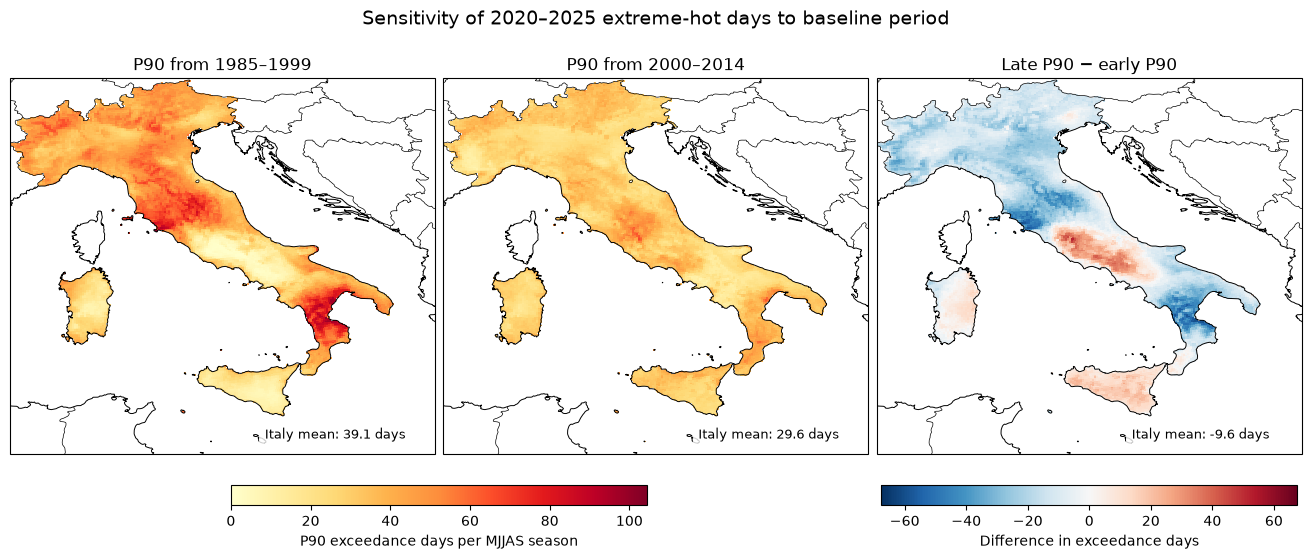

In [94]:
# Define sensitivity fields
sensitivity_fields = [
    hot_days_pres_early_mean,
    hot_days_pres_late_mean,
    hot_days_threshold_difference
]

sensitivity_titles = [
    "P90 from 1985–1999",
    "P90 from 2000–2014",
    "Late P90 − early P90"
]

# Calculate Italy means
sensitivity_italy_means = [
    float(hot_days_pres_early_mean.mean()),
    float(hot_days_pres_late_mean.mean()),
    float(hot_days_threshold_difference.mean())
]

# Use the same scale for the two absolute fields
vmax_main = max(
    float(hot_days_pres_early_mean.max()),
    float(hot_days_pres_late_mean.max())
)

# Use a symmetric scale for the difference
vmax_change = float(
    np.abs(hot_days_threshold_difference).max()
)

# Create figure
fig, axes = plt.subplots(
    1, 3,
    figsize=(13, 5.5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

# Plot recent hot days using the early threshold
im0 = axes[0].pcolormesh(
    lon, lat, hot_days_pres_early_mean,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    vmin=0,
    vmax=vmax_main,
    shading="auto"
)

# Plot recent hot days using the late threshold
im1 = axes[1].pcolormesh(
    lon, lat, hot_days_pres_late_mean,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    vmin=0,
    vmax=vmax_main,
    shading="auto"
)

# Plot the difference caused by threshold choice
im2 = axes[2].pcolormesh(
    lon, lat, hot_days_threshold_difference,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-vmax_change,
    vmax=vmax_change,
    shading="auto"
)

# Add common map formatting
for ax, title, mean_value in zip(
    axes,
    sensitivity_titles,
    sensitivity_italy_means
):
    ax.coastlines(resolution="10m", linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    ax.set_extent(
        [
            np.nanmin(lon),
            np.nanmax(lon),
            np.nanmin(lat),
            np.nanmax(lat)
        ],
        crs=ccrs.PlateCarree()
    )

    ax.set_title(title)

    ax.text(
        0.60, 0.07,
        f"Italy mean: {mean_value:+.1f} days"
        if ax == axes[2]
        else f"Italy mean: {mean_value:.1f} days",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.8
        )
    )

# Add colourbar for recent hot days
cbar1 = fig.colorbar(
    im1,
    ax=axes[:2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.07
)
cbar1.set_label("P90 exceedance days per MJJAS season")

# Add colourbar for sensitivity
cbar2 = fig.colorbar(
    im2,
    ax=axes[2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.07
)
cbar2.set_label("Difference in exceedance days")

# Add figure title
fig.suptitle(
    "Sensitivity of 2020–2025 extreme-hot days to baseline period",
    fontsize=14
)

plt.savefig(
    plots_path / "hot_days_sensitivity_to_baseline_period.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Sensitivity of daytime heatwave days

In [95]:
# Detect recent heatwave days using the 1985–1999 P90 threshold
hw_pres_early = hot_pres_early.groupby("time.year").map(
    detect_heatwave_days
)

# Detect recent heatwave days using the 2000–2014 P90 threshold
hw_pres_late = hot_pres_late.groupby("time.year").map(
    detect_heatwave_days
)

In [96]:
# Count recent heatwave days using the early threshold
hw_days_pres_early_yearly = (
    hw_pres_early.groupby("time.year").sum(dim="time")
)

# Count recent heatwave days using the late threshold
hw_days_pres_late_yearly = (
    hw_pres_late.groupby("time.year").sum(dim="time")
)

# Restore the Italian land mask
hw_days_pres_early_yearly = hw_days_pres_early_yearly.where(land_mask)
hw_days_pres_late_yearly = hw_days_pres_late_yearly.where(land_mask)

# Calculate mean heatwave days per MJJAS season
hw_days_pres_early_mean = hw_days_pres_early_yearly.mean(dim="year")
hw_days_pres_late_mean = hw_days_pres_late_yearly.mean(dim="year")

# Calculate sensitivity to the baseline threshold
hw_days_threshold_difference = (
    hw_days_pres_late_mean - hw_days_pres_early_mean
)

In [97]:
# Print Italy-mean sensitivity of recent heatwave days
print(
    f"2020–2025 heatwave days using 1985–1999 P90: "
    f"{float(hw_days_pres_early_mean.mean()):.1f} days/season"
)

print(
    f"2020–2025 heatwave days using 2000–2014 P90: "
    f"{float(hw_days_pres_late_mean.mean()):.1f} days/season"
)

print(
    f"Difference caused by threshold choice: "
    f"{float(hw_days_threshold_difference.mean()):+.1f} days/season"
)

2020–2025 heatwave days using 1985–1999 P90: 28.9 days/season
2020–2025 heatwave days using 2000–2014 P90: 19.3 days/season
Difference caused by threshold choice: -9.6 days/season


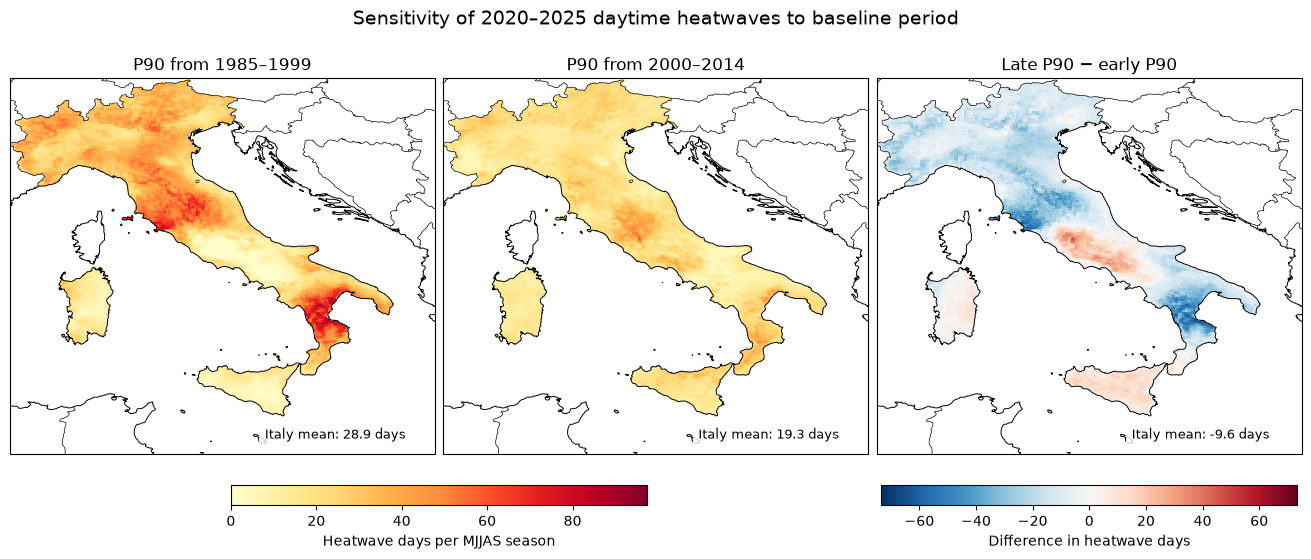

In [99]:
# Define heatwave sensitivity fields
hw_sensitivity_fields = [
    hw_days_pres_early_mean,
    hw_days_pres_late_mean,
    hw_days_threshold_difference
]

hw_sensitivity_titles = [
    "P90 from 1985–1999",
    "P90 from 2000–2014",
    "Late P90 − early P90"
]

# Calculate Italy means
hw_sensitivity_italy_means = [
    float(hw_days_pres_early_mean.mean()),
    float(hw_days_pres_late_mean.mean()),
    float(hw_days_threshold_difference.mean())
]

# Use the same scale for the two absolute fields
vmax_main = max(
    float(hw_days_pres_early_mean.max()),
    float(hw_days_pres_late_mean.max())
)

# Use a symmetric scale for the threshold sensitivity
vmax_change = float(
    np.abs(hw_days_threshold_difference).max()
)

# Create figure
fig, axes = plt.subplots(
    1, 3,
    figsize=(13, 5.5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

# Plot heatwave days using the early threshold
im0 = axes[0].pcolormesh(
    lon, lat, hw_days_pres_early_mean,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    vmin=0,
    vmax=vmax_main,
    shading="auto"
)

# Plot heatwave days using the late threshold
im1 = axes[1].pcolormesh(
    lon, lat, hw_days_pres_late_mean,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    vmin=0,
    vmax=vmax_main,
    shading="auto"
)

# Plot the difference caused by threshold choice
im2 = axes[2].pcolormesh(
    lon, lat, hw_days_threshold_difference,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-vmax_change,
    vmax=vmax_change,
    shading="auto"
)

# Add common map formatting
for ax, title, mean_value in zip(
    axes,
    hw_sensitivity_titles,
    hw_sensitivity_italy_means
):
    ax.coastlines(resolution="10m", linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    ax.set_extent(
        [
            np.nanmin(lon),
            np.nanmax(lon),
            np.nanmin(lat),
            np.nanmax(lat)
        ],
        crs=ccrs.PlateCarree()
    )

    ax.set_title(title)

    # Add Italy-mean values
    ax.text(
        0.60, 0.07,
        f"Italy mean: {mean_value:+.1f} days"
        if ax == axes[2]
        else f"Italy mean: {mean_value:.1f} days",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.8
        )
    )

# Add colourbar for absolute heatwave days
cbar1 = fig.colorbar(
    im1,
    ax=axes[:2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.07
)
cbar1.set_label("Heatwave days per MJJAS season")

# Add colourbar for sensitivity
cbar2 = fig.colorbar(
    im2,
    ax=axes[2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.07
)
cbar2.set_label("Difference in heatwave days")

# Add figure title
fig.suptitle(
    "Sensitivity of 2020–2025 daytime heatwaves to baseline period",
    fontsize=14
)

plt.savefig(
    plots_path / "heatwave_days_sensitivity_to_baseline_period.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# 5) Hot days (fixed threshold)

Define: 
- hot days: $T_{max} > 30°C$
- very hot days: $T_{max} > 35°C$

In [100]:
# Identify days with Tmax >= 30 °C
hot30_base = tmax_base >= 30
hot30_pres = tmax_pres >= 30

# Identify days with Tmax >= 35 °C
hot35_base = tmax_base >= 35
hot35_pres = tmax_pres >= 35

In [101]:
# Count >=30 °C days separately for each year
hot30_base_yearly = hot30_base.groupby("time.year").sum(dim="time")
hot30_pres_yearly = hot30_pres.groupby("time.year").sum(dim="time")

# Count >=35 °C days separately for each year
hot35_base_yearly = hot35_base.groupby("time.year").sum(dim="time")
hot35_pres_yearly = hot35_pres.groupby("time.year").sum(dim="time")

In [102]:
# Restore the Italian land mask
hot30_base_yearly = hot30_base_yearly.where(land_mask)
hot30_pres_yearly = hot30_pres_yearly.where(land_mask)

hot35_base_yearly = hot35_base_yearly.where(land_mask)
hot35_pres_yearly = hot35_pres_yearly.where(land_mask)

In [103]:
# Calculate mean number of >=30 °C days per season
hot30_base_mean = hot30_base_yearly.mean(dim="year")
hot30_pres_mean = hot30_pres_yearly.mean(dim="year")
hot30_change = hot30_pres_mean - hot30_base_mean

# Calculate mean number of >=35 °C days per season
hot35_base_mean = hot35_base_yearly.mean(dim="year")
hot35_pres_mean = hot35_pres_yearly.mean(dim="year")
hot35_change = hot35_pres_mean - hot35_base_mean

In [104]:
# Print Italy-mean fixed-threshold hot-day statistics
print(
    f"Tmax >= 30 °C: "
    f"{float(hot30_base_mean.mean()):.1f} → "
    f"{float(hot30_pres_mean.mean()):.1f} days "
    f"({float(hot30_change.mean()):+.1f})"
)

print(
    f"Tmax >= 35 °C: "
    f"{float(hot35_base_mean.mean()):.1f} → "
    f"{float(hot35_pres_mean.mean()):.1f} days "
    f"({float(hot35_change.mean()):+.1f})"
)

Tmax >= 30 °C: 26.5 → 34.4 days (+7.9)
Tmax >= 35 °C: 4.0 → 5.9 days (+1.9)


## Plot

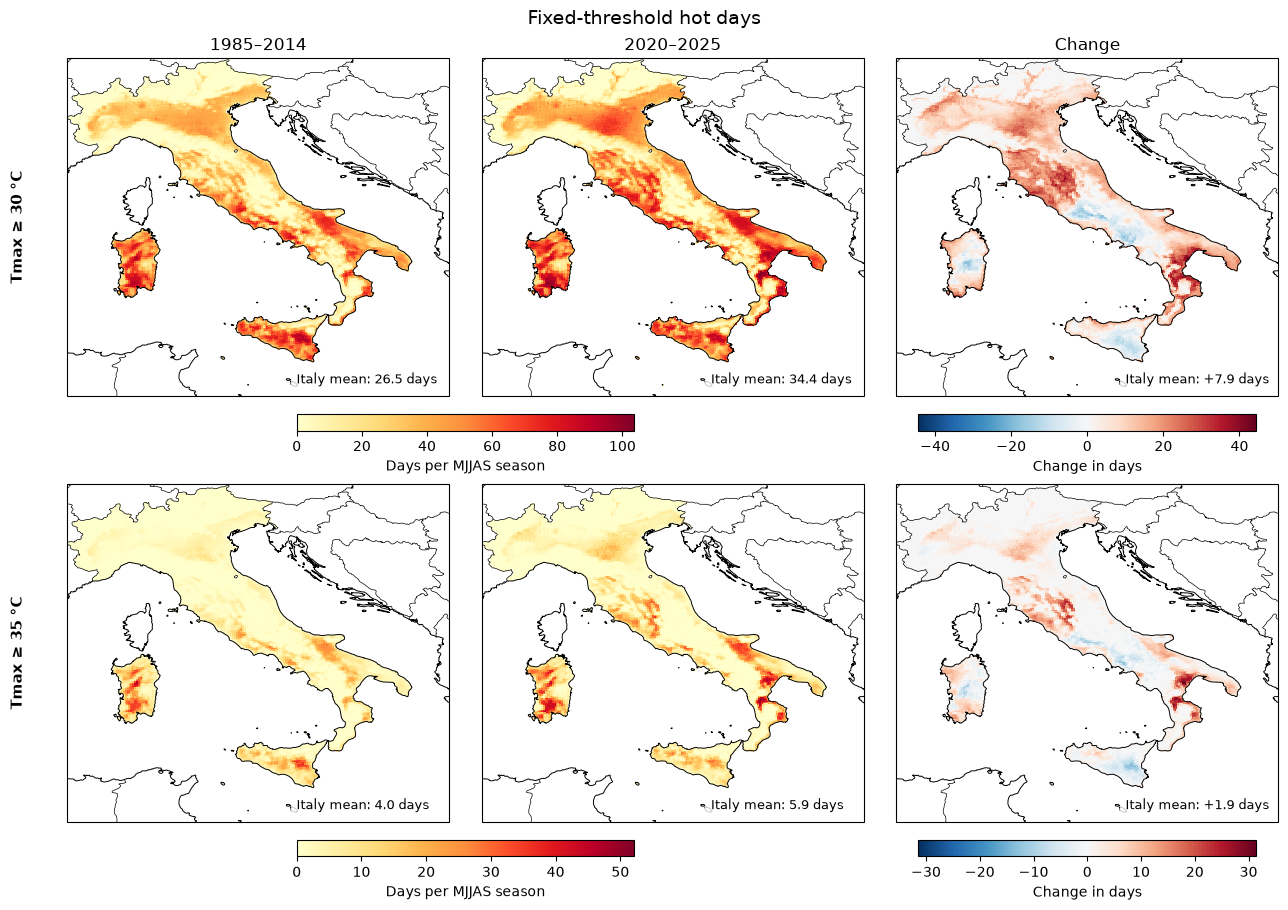

In [109]:
# Define fixed-threshold hot-day fields
hotday_grid = [
    [
        hot30_base_mean,
        hot30_pres_mean,
        hot30_change
    ],
    [
        hot35_base_mean,
        hot35_pres_mean,
        hot35_change
    ]
]

# Define column and row labels
col_titles = [
    "1985–2014",
    "2020–2025",
    "Change"
]

row_titles = [
    "Tmax ≥ 30 °C",
    "Tmax ≥ 35 °C"
]

# Calculate Italy-mean values
hotday_italy_means = [
    [
        float(hot30_base_mean.mean()),
        float(hot30_pres_mean.mean()),
        float(hot30_change.mean())
    ],
    [
        float(hot35_base_mean.mean()),
        float(hot35_pres_mean.mean()),
        float(hot35_change.mean())
    ]
]

# Define separate absolute scales for 30 °C and 35 °C days
vmax_main = [
    max(
        float(hot30_base_mean.max()),
        float(hot30_pres_mean.max())
    ),
    max(
        float(hot35_base_mean.max()),
        float(hot35_pres_mean.max())
    )
]

# Define separate change scales for 30 °C and 35 °C days
vmax_change = [
    max(
        float(np.abs(hot30_change.min())),
        float(np.abs(hot30_change.max()))
    ),
    max(
        float(np.abs(hot35_change.min())),
        float(np.abs(hot35_change.max()))
    )
]

# Create figure
fig, axes = plt.subplots(
    2, 3,
    figsize=(13, 9),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

# Store plot objects for the colourbars
im_main = [None, None]
im_change = [None, None]

# Plot all fields
for i in range(2):
    for j in range(3):

        ax = axes[i, j]
        field = hotday_grid[i][j]
        mean_value = hotday_italy_means[i][j]

        # Plot baseline and present with row-specific scales
        if j < 2:
            im_main[i] = ax.pcolormesh(
                lon,
                lat,
                field,
                transform=ccrs.PlateCarree(),
                cmap="YlOrRd",
                vmin=0,
                vmax=vmax_main[i],
                shading="auto"
            )

        # Plot changes with row-specific diverging scales
        else:
            im_change[i] = ax.pcolormesh(
                lon,
                lat,
                field,
                transform=ccrs.PlateCarree(),
                cmap="RdBu_r",
                vmin=-vmax_change[i],
                vmax=vmax_change[i],
                shading="auto"
            )

        # Add map features
        ax.coastlines(resolution="10m", linewidth=0.7)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        # Set map extent
        ax.set_extent(
            [
                np.nanmin(lon),
                np.nanmax(lon),
                np.nanmin(lat),
                np.nanmax(lat)
            ],
            crs=ccrs.PlateCarree()
        )

        # Add column titles
        if i == 0:
            ax.set_title(col_titles[j])

        # Add Italy-mean values
        ax.text(
            0.60, 0.07,
            f"Italy mean: {mean_value:+.1f} days"
            if j == 2
            else f"Italy mean: {mean_value:.1f} days",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.8
            )
        )

# Add row labels
for i, label in enumerate(row_titles):
    axes[i, 0].text(
        -0.13, 0.5,
        label,
        transform=axes[i, 0].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# Add colourbars for ≥30 °C days
cbar30 = fig.colorbar(
    im_main[0],
    ax=axes[0, :2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.05
)
cbar30.set_label("Days per MJJAS season")

cbar30_change = fig.colorbar(
    im_change[0],
    ax=axes[0, 2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.05
)
cbar30_change.set_label("Change in days")

# Add colourbars for ≥35 °C days
cbar35 = fig.colorbar(
    im_main[1],
    ax=axes[1, :2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.05
)
cbar35.set_label("Days per MJJAS season")

cbar35_change = fig.colorbar(
    im_change[1],
    ax=axes[1, 2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.05
)
cbar35_change.set_label("Change in days")

# Add figure title
fig.suptitle(
    "Fixed-threshold hot days",
    fontsize=14
)

plt.savefig(
    plots_path / "fixed_threshold_hot_days_change_2020-2025_minus_1985-2014.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# SUMMARY PLOTS

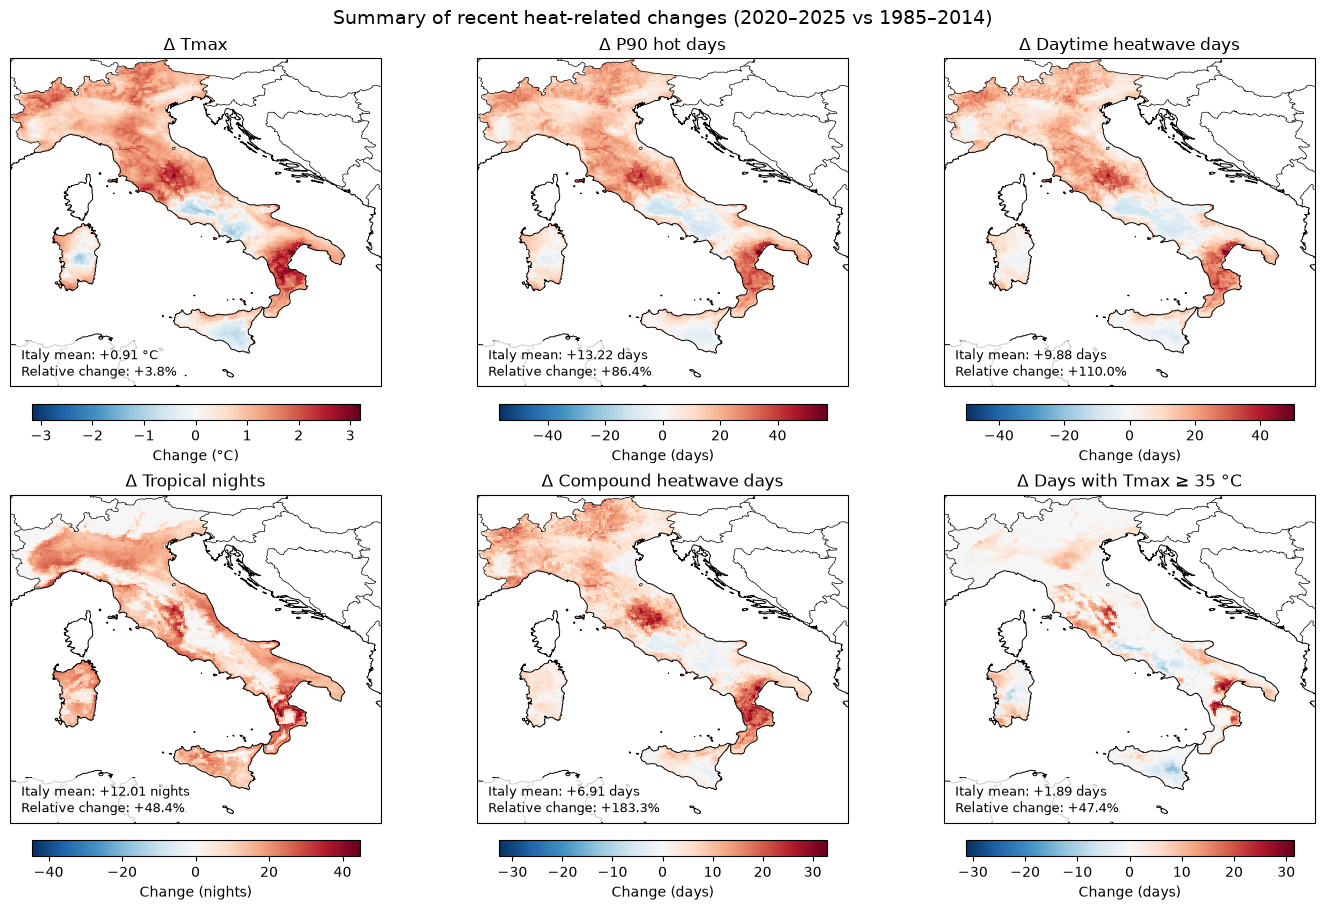

In [117]:
# Define summary change fields
summary_fields = [
    tmax_change.squeeze(drop=True),
    hot_days_change,
    hw_days_change,
    tn_change,
    compound_hw_days_change,
    hot35_change
]

# Define panel titles
summary_titles = [
    "Δ Tmax",
    "Δ P90 hot days",
    "Δ Daytime heatwave days",
    "Δ Tropical nights",
    "Δ Compound heatwave days",
    "Δ Days with Tmax ≥ 35 °C"
]

# Define baseline means
summary_baselines = [
    float(tmax_base_mean.squeeze(drop=True).mean()),
    float(hot_days_base_mean.mean()),
    float(hw_days_base_mean.mean()),
    float(tn_base_mean.mean()),
    float(compound_hw_days_base_mean.mean()),
    float(hot35_base_mean.mean())
]

# Define present means
summary_presents = [
    float(tmax_pres_mean.squeeze(drop=True).mean()),
    float(hot_days_pres_mean.mean()),
    float(hw_days_pres_mean.mean()),
    float(tn_pres_mean.mean()),
    float(compound_hw_days_pres_mean.mean()),
    float(hot35_pres_mean.mean())
]

# Define Italy-mean absolute changes
summary_changes = [
    float(tmax_change.squeeze(drop=True).mean()),
    float(hot_days_change.mean()),
    float(hw_days_change.mean()),
    float(tn_change.mean()),
    float(compound_hw_days_change.mean()),
    float(hot35_change.mean())
]

# Calculate Italy-mean relative changes
summary_pct = [
    (present - base) / base * 100
    for base, present in zip(summary_baselines, summary_presents)
]

# Define units for each panel
summary_units = [
    "°C",
    "days",
    "days",
    "nights",
    "days",
    "days"
]

# Create figure
fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 9),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

# Flatten axes for easier looping
axes = axes.flatten()

# Plot each change map
for ax, field, title, mean_change, pct_change, unit in zip(
    axes,
    summary_fields,
    summary_titles,
    summary_changes,
    summary_pct,
    summary_units
):
    vmax = max(
        abs(float(field.min())),
        abs(float(field.max()))
    )

    im = ax.pcolormesh(
        lon,
        lat,
        field,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
        shading="auto"
    )

    ax.coastlines(resolution="10m", linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    ax.set_extent(
        [
            np.nanmin(lon),
            np.nanmax(lon),
            np.nanmin(lat),
            np.nanmax(lat)
        ],
        crs=ccrs.PlateCarree()
    )

    ax.set_title(title)

    ax.text(
        0.03, 0.12,
        f"Italy mean: {mean_change:+.2f} {unit}\n"
        f"Relative change: {pct_change:+.1f}%",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.8
        )
    )

    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        fraction=0.05,
        pad=0.05
    )
    cbar.set_label(f"Change ({unit})")

# Add figure title
fig.suptitle(
    "Summary of recent heat-related changes (2020–2025 vs 1985–2014)",
    fontsize=14
)

plt.savefig(
    plots_path / "summary_heat_related_changes_2020-2025_minus_1985-2014.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

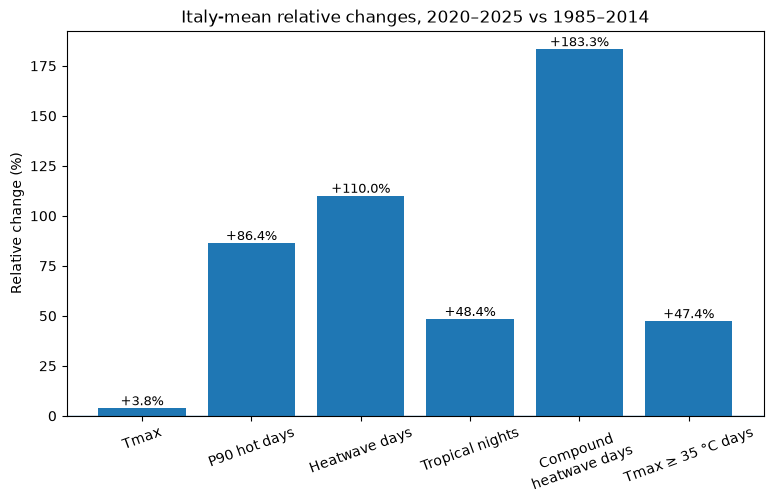

In [116]:
# Define labels for the bar chart
bar_labels = [
    "Tmax",
    "P90 hot days",
    "Heatwave days",
    "Tropical nights",
    "Compound\nheatwave days",
    "Tmax ≥ 35 °C days"
]

# Create figure
fig, ax = plt.subplots(figsize=(9, 5))

# Plot Italy-mean relative changes
bars = ax.bar(
    bar_labels,
    summary_pct
)

# Add zero line
ax.axhline(0, linewidth=1)

# Add value labels above bars
for bar, value in zip(bars, summary_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:+.1f}%",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=9
    )

# Add labels and title
ax.set_ylabel("Relative change (%)")
ax.set_title("Italy-mean relative changes, 2020–2025 vs 1985–2014")

plt.xticks(rotation=20)
plt.savefig(
    plots_path / "summary_italy_heat_related_relative_changes_2020-2025_minus_1985-2014.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()